# In-Class Live-Coded Bloch Equation Simulator 

Simulate the response of magnetization to time-varying changes in the $B_0$ and $B_1$ fields.  

In [52]:

%matplotlib inline
import numpy as np
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Checkbox
from IPython.display import clear_output, display, HTML
import matplotlib.pyplot as plt


In [53]:

def rotx(theta):
    R = np.zeros((3,3))
    R[0,0] = 1.0 
    R[1,1] = np.cos(theta)
    R[1,2] = -np.sin(theta) 
    R[2,1] = np.sin(theta) 
    R[2,2] = np.cos(theta) 
    return R 

def roty(theta):
    R = np.zeros((3,3))
    R[0,0] = np.cos(theta)
    R[0,2] = np.sin(theta) 
    R[1,1] = 1.0
    R[2,0] = -np.sin(theta) 
    R[2,2] = np.cos(theta) 
    return R 

def rotz(theta):
    R = np.zeros((3,3))
    R[0,0] = np.cos(theta)
    R[0,1] = -np.sin(theta) 
    R[1,0] = np.sin(theta) 
    R[1,1] = np.cos(theta) 
    R[2,2] = 1.0 
    return R 

def bloch_sim_no_gradient(B1: np.ndarray,       # complex-valued because it contains x and y components  [Tesla]
                          delta_B0: np.ndarray, # floating point valued off-resonance values vector [Tesla]
                          M0: np.ndarray, # intial magnetization vector [0,0,1]
                          delta_t: float, # value in seconds for the time step 
                          T1: float, 
                          T2: float, 
                          gamma: float=2*np.pi*42.58e6):
    
    ntime = B1.size 
    nfreq = delta_B0.size 

    # allocate and initialize the magnetization
    M = np.zeros((3, nfreq, ntime+1))
    for f in range(nfreq):
        M[:,f,0] = M0

    # define the "relaxation" matrix 
    relax = np.zeros((3,3))
    relax[0,0] = np.exp(-delta_t/T2)
    relax[1,1] = np.exp(-delta_t/T2)
    relax[2,2] = np.exp(-delta_t/T1)

    for t in range(ntime): 
        
        # calculate the rotation angles at current time step for B1 field 
        omega_x = np.real(B1[t]) * gamma 
        theta_x = omega_x * delta_t 
        omega_y = np.imag(B1[t]) * gamma 
        theta_y = omega_y * delta_t 

        # make x and y rotation matrices 
        Rx = rotx(theta_x)
        Ry = roty(theta_y)

        # loop over all delta b0 values 
        for f in range(nfreq):

            omega_z = delta_B0[f] * gamma 
            theta_z = omega_z * delta_t 

            # make z rotation matrix
            Rz = rotz(theta_z)

            # carrying out small rotations due to the B1 field and errors in B0
            M[:,f,t+1] = Rz @ Ry @ Rx @ M[:,f,t]

            # simulate relaxation 
            M[:,f,t+1] = relax @ M[:,f,t+1] 
            M[2,f,t+1] = M[2,f,t+1] + 1 - np.exp(-delta_t/T1) # add additional recovery term to Mz (per differential equation solved in class)

    return M 



In [60]:

gamma = 2 * np.pi * 42.58e6 # [rad/s/T]
tau = 1e-3             # duration of the B1 pulse in seconds 
alpha = 10 * np.pi / 180 # converted flip angle to radians 
T1 = np.inf 
T2 = 0.11

# calculate amplitude of B1 pulse to achieve a flip angle of alpha  [ Tesla ]
B1_amplitude = alpha / (gamma * tau)

# duration of each discrete time step [seconds]
delta_t = 1e-6 

# make the B1(t) waveform 
ntime = int(tau / delta_t)
B1 = B1_amplitude * np.ones((ntime,), np.complex64)

# set up the delta_B0 array [Tesla]
num_delta_B0 = 101
delta_B0_Hz = np.linspace(-2000, 2000, num_delta_B0)
delta_B0 = delta_B0_Hz / (gamma / (2*np.pi)) # convert to Tesla 

# set initial magnetization vector with mz=1
M0 = np.zeros((3,))
M0[2] = 1.0 

Mt = bloch_sim_no_gradient(B1, delta_B0, M0, delta_t, T1, T2)


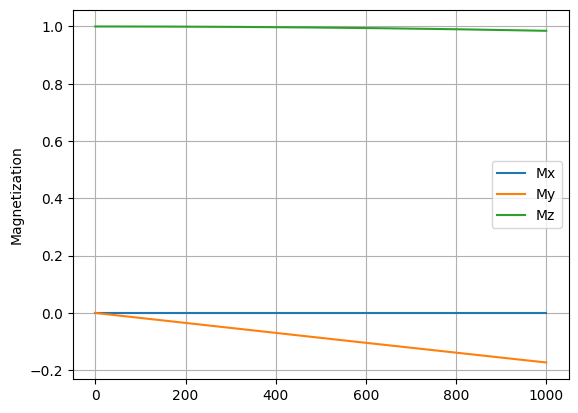

In [61]:

Mxt = Mt[0,:,:]
Myt = Mt[1,:,:]
Mzt = Mt[2,:,:]

Mxy = np.sqrt( Mxt**2 + Myt**2)

plt.figure() 
plt.plot(Mxt[50,:], label='Mx')
plt.plot(Myt[50,:], label='My')
plt.plot(Mzt[50,:], label='Mz')
plt.ylabel('Magnetization')
plt.legend()
plt.grid()
plt.show()

# Check to See if We Achieved FLip Angle 

9.955092105168367


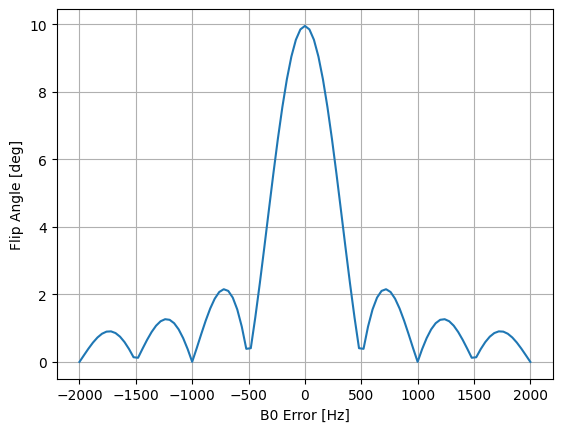

In [64]:

flip_angle_simulated = np.abs(np.arctan2(Myt, Mzt))
print(flip_angle_simulated[50,-1] * 180 / np.pi)

plt.figure()
plt.plot(delta_B0_Hz, flip_angle_simulated[:,-1]*180/np.pi)
plt.grid()
plt.xlabel('B0 Error [Hz]')
plt.ylabel('Flip Angle [deg]')
plt.show() 